# Previsão de Consumo Energético em Indústria Siderúrgica

## Por que escolhi esse problema

Energia elétrica é um dos maiores custos operacionais de qualquer
processo industrial contínuo. Durante meu estágio na TUPY, empresa
de fundição fornecedora do setor automotivo, acompanhei de perto
como decisões operacionais impactam diretamente a conta de energia
— lá, percebi que seria interessante de ter um maior controle da 
energia utilizada nos fornos.

A pergunta que motivou esse projeto foi direta: **é possível prever
o consumo de energia com antecedência suficiente para que um operador
tome decisões antes do horário mais caro da tarifa?**

Utilizei dados reais da DAEWOO Steel Co. (Coreia do Sul), disponíveis
publicamente no UCI Machine Learning Repository, com 35.040 registros
de consumo em intervalos de 15 minutos ao longo de 2018.

**Este é meu segundo projeto de portfólio.** O primeiro abordou
manutenção preditiva de equipamentos industriais com Random Forest.
Aqui avanço para séries temporais e regressão, com foco em
**quantificar o impacto financeiro em reais**.

**Tecnologias:** Python · Pandas · Scikit-learn · Matplotlib · Seaborn

**Autor:** Adálcio Hugo Gonçalves dos Santos
Engenheiro de Materiais — CEFET-MG

In [1]:
# ============================================================
# PROJETO 2 — Previsão de Consumo Energético Industrial
# DAEWOO Steel Co. Ltd — Gwangyang, Coreia do Sul
# Fonte: UCI Machine Learning Repository
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


In [2]:
df = pd.read_csv("Steel_industry_data.csv")

print(f"Linhas:  {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
print(f"\nPeríodo coberto: {df.shape[0] * 15 / 60 / 24:.0f} dias de dados")

Linhas:  35040
Colunas: 11

Período coberto: 365 dias de dados


In [3]:
df.head(10)

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load
5,01/01/2018 01:30,3.28,3.56,0.0,0.0,67.76,100.0,5400,Weekday,Monday,Light_Load
6,01/01/2018 01:45,3.60,4.14,0.0,0.0,65.62,100.0,6300,Weekday,Monday,Light_Load
7,01/01/2018 02:00,3.60,4.28,0.0,0.0,64.37,100.0,7200,Weekday,Monday,Light_Load
8,01/01/2018 02:15,3.28,3.64,0.0,0.0,66.94,100.0,8100,Weekday,Monday,Light_Load
9,01/01/2018 02:30,3.78,4.72,0.0,0.0,62.51,100.0,9000,Weekday,Monday,Light_Load


In [4]:
print("=== Tipos de dados ===")
print(df.dtypes)
print(f"\n=== Valores nulos ===")
print(df.isnull().sum())

=== Tipos de dados ===
date                                     object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                               object
Day_of_week                              object
Load_Type                                object
dtype: object

=== Valores nulos ===
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                       

In [5]:
df.describe().round(2)

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.00,35040.00,35040.00,35040.00,35040.00,35040.00,35040.00
mean,27.39,13.04,3.87,0.01,80.58,84.37,42750.00
std,33.44,16.31,7.42,0.02,18.92,30.46,24940.53
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,3.20,2.30,0.00,0.00,63.32,99.70,21375.00
50%,4.57,5.00,0.00,0.00,87.96,100.00,42750.00
75%,51.24,22.64,2.09,0.02,99.02,100.00,64125.00
max,157.18,96.91,27.76,0.07,100.00,100.00,85500.00


In [6]:
# ============================================================
# Processamento da coluna de data
# ============================================================

# Convertemos a string de data para datetime — formato que Python
# entende como tempo real, permitindo extrair hora, dia, mês etc.
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Definimos a data como índice — padrão para séries temporais
df = df.set_index("date")
df = df.sort_index()  # garante ordem cronológica

print("=== Período dos dados ===")
print(f"Início: {df.index.min()}")
print(f"Fim:    {df.index.max()}")
print(f"Total:  {len(df)} registros de 15 minutos")
print(f"\nPrimeiros registros:")
print(df["Usage_kWh"].head(8))

=== Período dos dados ===
Início: 2018-01-01 00:00:00
Fim:    2018-12-31 23:45:00
Total:  35040 registros de 15 minutos

Primeiros registros:
date
2018-01-01 00:00:00    3.42
2018-01-01 00:15:00    3.17
2018-01-01 00:30:00    4.00
2018-01-01 00:45:00    3.24
2018-01-01 01:00:00    3.31
2018-01-01 01:15:00    3.82
2018-01-01 01:30:00    3.28
2018-01-01 01:45:00    3.60
Name: Usage_kWh, dtype: float64


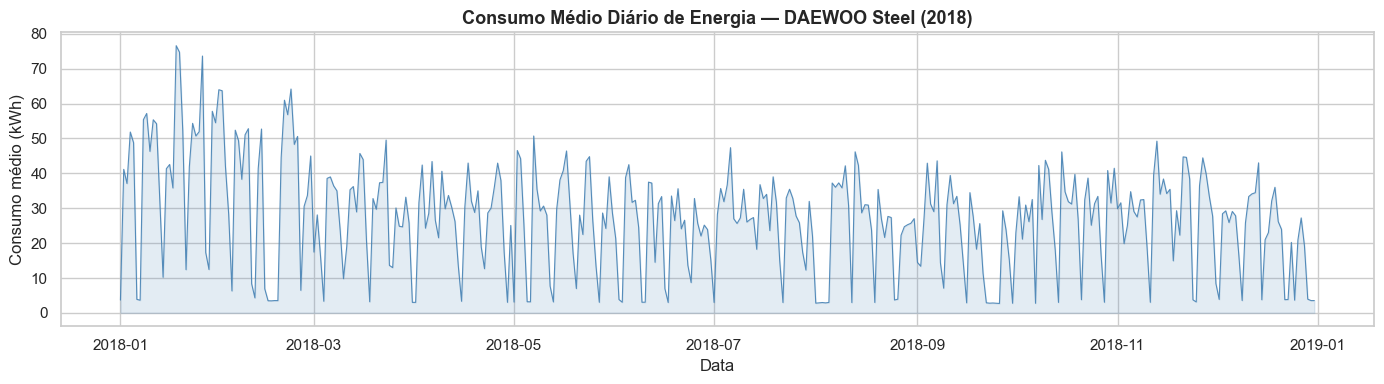

In [7]:
# Visão macro: como o consumo variou ao longo do ano inteiro?
# Em qualquer processo industrial, padrões sazonais indicam influência de temperatura, demanda de produção ou períodos de manutenção.

fig, ax = plt.subplots(figsize=(14, 4))

# Resample para visualização diária (média por dia)
consumo_diario = df["Usage_kWh"].resample("D").mean()

ax.plot(consumo_diario.index, consumo_diario.values,
        color="steelblue", linewidth=0.8, alpha=0.9)
ax.fill_between(consumo_diario.index, consumo_diario.values,
                alpha=0.15, color="steelblue")

ax.set_title("Consumo Médio Diário de Energia — DAEWOO Steel (2018)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Data")
ax.set_ylabel("Consumo médio (kWh)")
plt.tight_layout()
plt.savefig("consumo_anual.png", dpi=150, bbox_inches="tight")
plt.show()

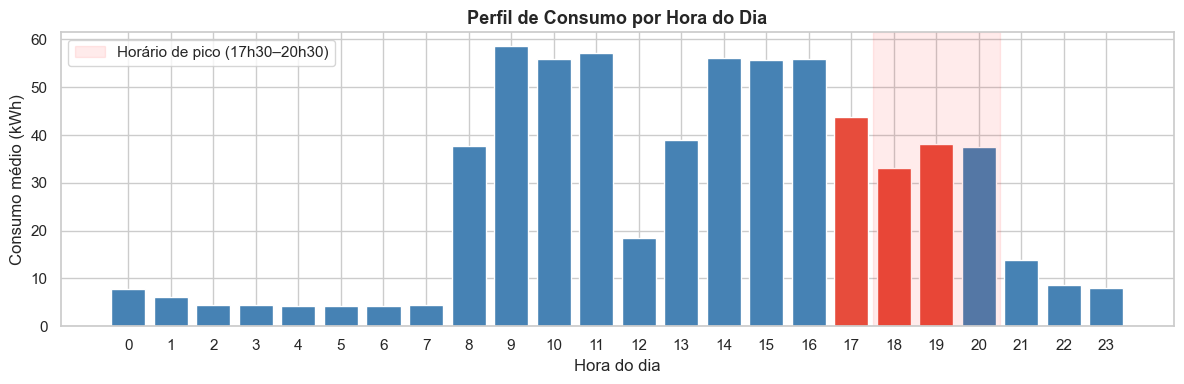

Consumo médio no horário de pico:      38.13 kWh
Consumo médio fora do horário de pico: 25.24 kWh
Diferença: 51.1%


In [8]:
# O perfil horário é a peça mais importante para a análise de custo.
# Se o consumo é alto no horário de ponta (17h30-20h30), há potencial real de economia por deslocamento de carga.

df["hora"] = df.index.hour

perfil_horario = df.groupby("hora")["Usage_kWh"].mean()

fig, ax = plt.subplots(figsize=(12, 4))
cores = ["#e74c3c" if (17 <= h < 20) else "steelblue"
         for h in perfil_horario.index]

bars = ax.bar(perfil_horario.index, perfil_horario.values,
              color=cores, edgecolor="white", width=0.8)

ax.axvspan(17.5, 20.5, alpha=0.08, color="red",
           label="Horário de pico (17h30–20h30)")
ax.set_title("Perfil de Consumo por Hora do Dia",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Consumo médio (kWh)")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig("perfil_horario.png", dpi=150, bbox_inches="tight")
plt.show()

# Quantificando o diferencial de ponta vs fora de ponta
ponta = df[df["hora"].between(17, 20)]["Usage_kWh"].mean()
fora_ponta = df[~df["hora"].between(17, 20)]["Usage_kWh"].mean()
print(f"Consumo médio no horário de pico:      {ponta:.2f} kWh")
print(f"Consumo médio fora do horário de pico: {fora_ponta:.2f} kWh")
print(f"Diferença: {((ponta/fora_ponta)-1)*100:.1f}%")

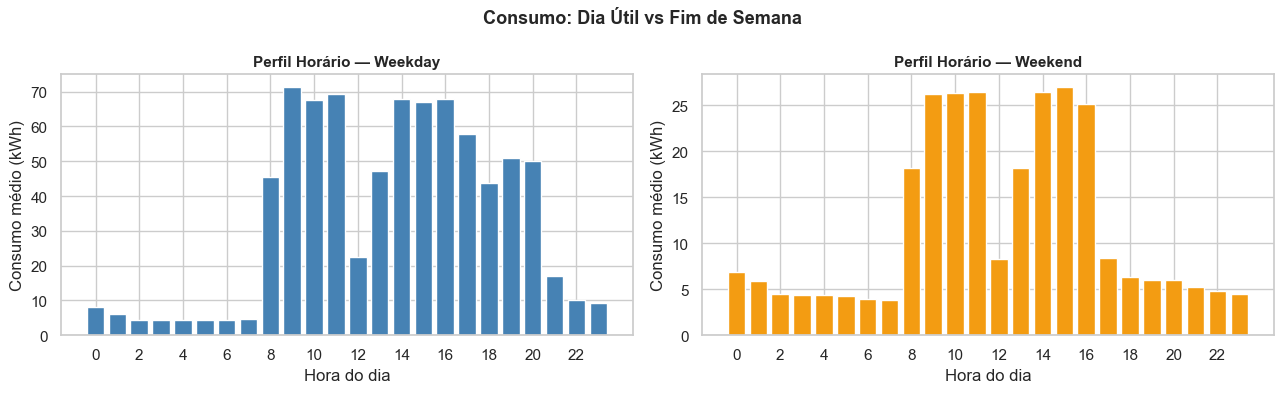

In [9]:
# Fábricas têm perfis de carga completamente diferentes em dias úteis vs fins de semana. Essa diferença precisa ser capturada pelo modelo.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, status in zip(axes, ["Weekday", "Weekend"]):
    dados = df[df["WeekStatus"] == status]
    perfil = dados.groupby("hora")["Usage_kWh"].mean()
    ax.bar(perfil.index, perfil.values,
           color="steelblue" if status == "Weekday" else "#f39c12",
           edgecolor="white", width=0.8)
    ax.set_title(f"Perfil Horário — {status}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Hora do dia")
    ax.set_ylabel("Consumo médio (kWh)")
    ax.set_xticks(range(0, 24, 2))

plt.suptitle("Consumo: Dia Útil vs Fim de Semana",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("perfil_semana.png", dpi=150, bbox_inches="tight")
plt.show()

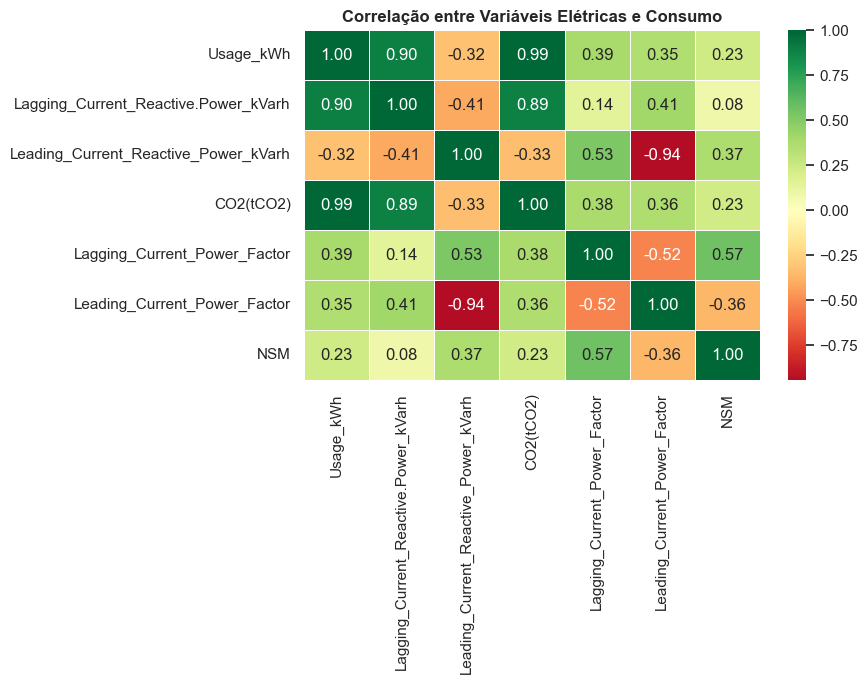

In [10]:
# ============================================================
# Correlação entre variáveis elétricas e consumo
# ============================================================
# Objetivo: identificar quais parâmetros elétricos estão mais associados ao consumo — esses serão os mais valiosos para o modelo preditivo.

colunas_numericas = [
    "Usage_kWh",
    "Lagging_Current_Reactive.Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh",
    "CO2(tCO2)",
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor",
    "NSM"
]

fig, ax = plt.subplots(figsize=(9, 7))
matriz_corr = df[colunas_numericas].corr()

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Correlação entre Variáveis Elétricas e Consumo",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("correlacao_energia.png", dpi=150, bbox_inches="tight")
plt.show()

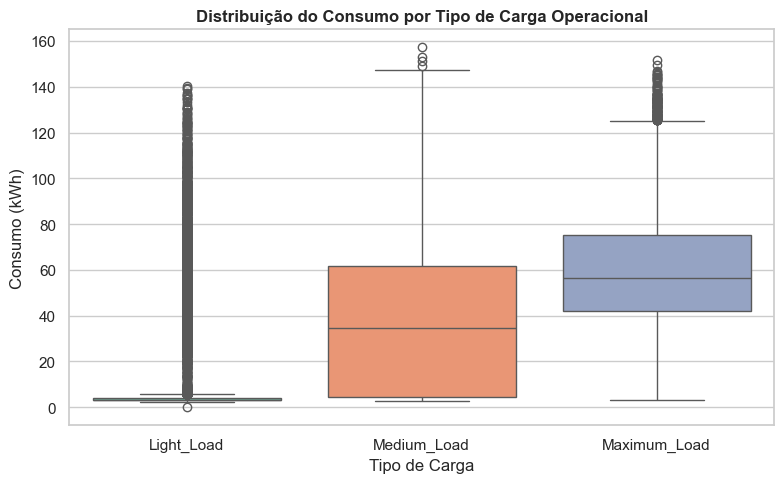

In [11]:
# Distribuição do consumo por tipo de carga
# O Load_Type é a classificação operacional da fábrica:
# Light = operação leve, Medium = operação normal, Maximum = pico de produção

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Load_Type",
    y="Usage_kWh",
    hue="Load_Type",      # ← correção: hue recebe a variável de cor
    legend=False,          # ← correção: remove a legenda redundante
    palette="Set2",
    order=["Light_Load", "Medium_Load", "Maximum_Load"],
    ax=ax
)

ax.set_title("Distribuição do Consumo por Tipo de Carga Operacional",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Tipo de Carga")
ax.set_ylabel("Consumo (kWh)")
plt.tight_layout()
plt.savefig("consumo_por_carga.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# OBSERVAÇÃO: Light_Load apresenta outliers acima de 130 kWh, o que parece contraditório. 
# Porém, Load_Type é classificado por múltiplos fatores elétricos (potência reativa, fator de potência), não só pelo consumo bruto. O modelo precisará aprender essa relação.

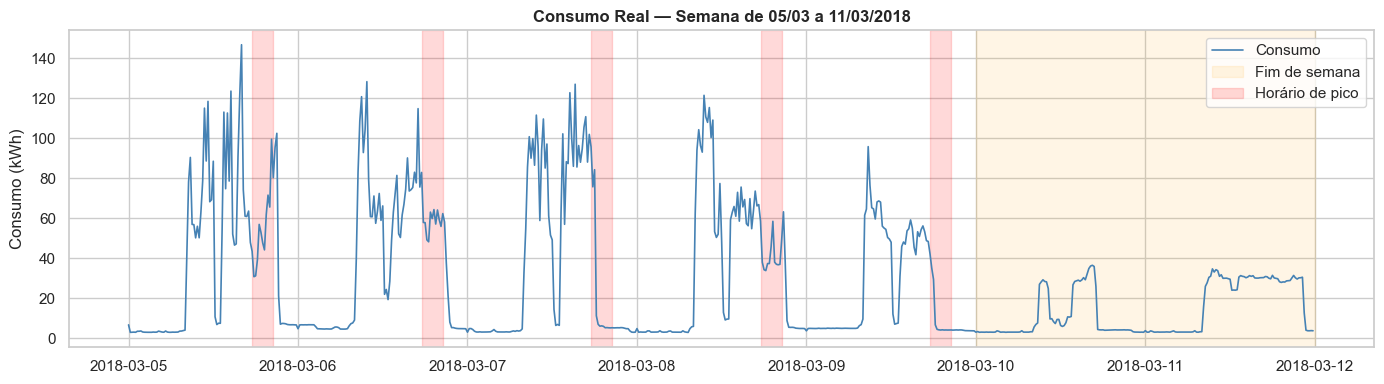

In [13]:
# Vamos visualisar algumas semanas de dados e verificar o uso de energia nos horários de pico.

semana = df["2018-03-05":"2018-03-11"]["Usage_kWh"]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(semana.index, semana.values,
        color="steelblue", linewidth=1.2)

# Marca os fins de semana
ax.axvspan(pd.Timestamp("2018-03-10"),
           pd.Timestamp("2018-03-11 23:59"),
           alpha=0.1, color="orange", label="Fim de semana")

# Marca horários de ponta de cada dia útil
for dia in pd.date_range("2018-03-05", "2018-03-09"):
    ponta_ini = dia + pd.Timedelta(hours=17, minutes=30)
    ponta_fim = dia + pd.Timedelta(hours=20, minutes=30)
    ax.axvspan(ponta_ini, ponta_fim,
               alpha=0.15, color="red")

ax.set_title("Consumo Real — Semana de 05/03 a 11/03/2018",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Consumo (kWh)")
ax.legend(["Consumo", "Fim de semana", "Horário de pico"])
plt.tight_layout()
plt.savefig("semana_tipica.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Alguns horários de ponta tem consumo quase zerado, enquanto outros chegam a 100+ kWh. Isso revela duas coisas: 
# Esta fábrica já pratica gerenciamento de carga em alguns dias. Possivelmente quando o planejamento de produção permite.
# Nos dias que isso não acontece, há um custo evitável. Irei trabalhar nisto. O modelo deverá prever com antecedência quando o consumo vai ser alto nos horários de pico.

In [15]:
# ============================================================
# FASE 3 — Engenharia de Features Temporais
# ============================================================
# O modelo não entende "17h30 é horário de pico". Precisamos traduzir isso em colunas numéricas.
# Cada linha abaixo adiciona uma "memória" diferente ao modelo.

df_model = df.copy()

# --- Features de calendário ---
# O modelo aprende que sexta à tarde tem perfil diferente
# de terça de manhã, por exemplo.
df_model["hora"]        = df_model.index.hour
df_model["minuto"]      = df_model.index.minute
df_model["dia_semana"]  = df_model.index.dayofweek   # 0=segunda, 6=domingo
df_model["mes"]         = df_model.index.month
df_model["dia_ano"]     = df_model.index.dayofyear

# --- Feature crítica: é horário de ponta? ---
# Converte a informação tarifária em binário para o modelo.
# 1 = tarifa cara, 0 = tarifa normal
df_model["horario_ponta"] = (
    (df_model["hora"] >= 17) & (df_model["hora"] < 20)
).astype(int)

print(f"Registros em horário de ponta: "
      f"{df_model['horario_ponta'].sum()} "
      f"({df_model['horario_ponta'].mean()*100:.1f}%)")

Registros em horário de ponta: 4380 (12.5%)


In [48]:
# --- Features de lag ---
# A ideia: o consumo agora depende do consumo recente.
# Se a fábrica estava consumindo 80 kWh há 15 minutos, é provável que ainda esteja consumindo perto disso agora.
#
# Lag 1  = consumo 15 minutos atrás
# Lag 4  = consumo 1 hora atrás
# Lag 96 = consumo 24 horas atrás (mesmo horário ontem)

for lag in [1, 2, 3, 4, 8, 96]:
    df_model[f"lag_{lag}"] = df_model["Usage_kWh"].shift(lag)

# --- Médias móveis ---
# Suavizam o ruído e capturam a tendência recente do processo
df_model["media_movel_1h"]  = (df_model["Usage_kWh"]
                                .shift(1).rolling(4).mean())
df_model["media_movel_4h"]  = (df_model["Usage_kWh"]
                                .shift(1).rolling(16).mean())
df_model["media_movel_24h"] = (df_model["Usage_kWh"]
                                .shift(1).rolling(96).mean())

# Removemos linhas com NaN gerados pelos lags
# (as primeiras linhas não têm histórico suficiente)
df_model = df_model.dropna()

print(f"Dataset após engenharia de features:")
print(f"Linhas:  {df_model.shape[0]}")
print(f"Colunas: {df_model.shape[1]}")
print(f"\nNovas features criadas:")
novas = [c for c in df_model.columns if c not in df.columns]
print(novas)

Dataset após engenharia de features:
Linhas:  34848
Colunas: 25

Novas features criadas:
['minuto', 'dia_semana', 'mes', 'dia_ano', 'horario_ponta', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_8', 'lag_96', 'media_movel_1h', 'media_movel_4h', 'media_movel_24h']


In [17]:
from sklearn.model_selection import train_test_split

# Variáveis categóricas viram números
df_encoded = pd.get_dummies(
    df_model,
    columns=["WeekStatus", "Day_of_week", "Load_Type"],
    drop_first=False
)

# Variável-alvo
y = df_encoded["Usage_kWh"]

# Features de entrada — removemos a variável-alvo
# e CO2 (é derivado do consumo, seria "cola")
X = df_encoded.drop(columns=["Usage_kWh", "CO2(tCO2)"])

# Divisão temporal
# Usaremos os primeiros 80% para treinar e os últimos 20% para testar, tentando simular um cenário real.

split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Treino: {len(X_train)} registros "
      f"({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"Teste:  {len(X_test)} registros "
      f"({X_test.index.min().date()} → {X_test.index.max().date()})")
print(f"\nTotal de features: {X_train.shape[1]}")

Treino: 27955 registros (2018-01-02 → 2018-10-20)
Teste:  6989 registros (2018-10-20 → 2018-12-31)

Total de features: 32


In [18]:
# ============================================================
# FASE 4 — Modelo de Regressão
# ============================================================
from sklearn.ensemble import RandomForestRegressor

# n_estimators=200: 200 árvores de decisão votando juntas
# n_jobs=-1: usa todos os núcleos do processador — treina mais rápido
# random_state=42: reprodutibilidade
modelo = RandomForestRegressor(
    n_estimators=200,
    n_jobs=-1,
    random_state=42
)

modelo.fit(X_train, y_train)
print("Modelo treinado.")
print(f"Features utilizadas: {modelo.n_features_in_}")


Modelo treinado.
Features utilizadas: 32


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = modelo.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)
mape = (abs((y_test - y_pred) / y_test.replace(0, 1))).mean() * 100

print("=== Métricas de Avaliação ===")
print(f"MAE  (Erro Médio Absoluto):      {mae:.2f} kWh")
print(f"RMSE (Raiz do Erro Quadrático):  {rmse:.2f} kWh")
print(f"R²   (Coeficiente de Determinação): {r2:.4f}")
print(f"MAPE (Erro Percentual Médio):    {mape:.1f}%")
print(f"\nConsumo médio real no período de teste: "
      f"{y_test.mean():.2f} kWh")
print(f"Erro médio representa {(mae/y_test.mean()*100):.1f}% "
      f"do consumo médio")

=== Métricas de Avaliação ===
MAE  (Erro Médio Absoluto):      0.95 kWh
RMSE (Raiz do Erro Quadrático):  2.38 kWh
R²   (Coeficiente de Determinação): 0.9943
MAPE (Erro Percentual Médio):    7.8%

Consumo médio real no período de teste: 25.27 kWh
Erro médio representa 3.8% do consumo médio


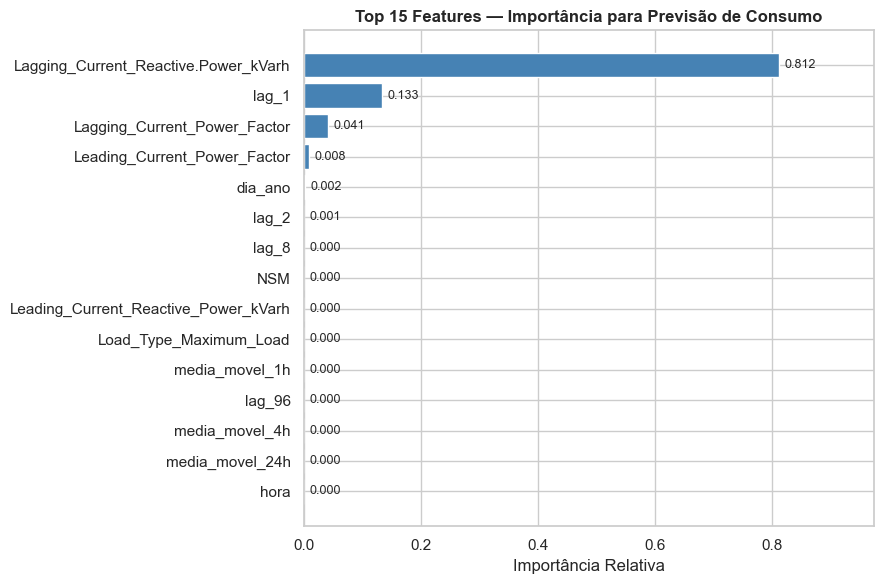

In [20]:
# Vamos verificar também quais variáveis o modelo considerou mais importantes.
# Isso responde a pergunta: "o que mais explica o consumo de energia nessa planta siderúrgica?"

importancias = pd.Series(
    modelo.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True).tail(15)  # top 15

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importancias.index, importancias.values,
               color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
ax.set_title("Top 15 Features — Importância para Previsão de Consumo",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importância Relativa")
ax.set_xlim(0, importancias.values.max() * 1.2)
plt.tight_layout()
plt.savefig("importancia_features.png", dpi=150, bbox_inches="tight")
plt.show()

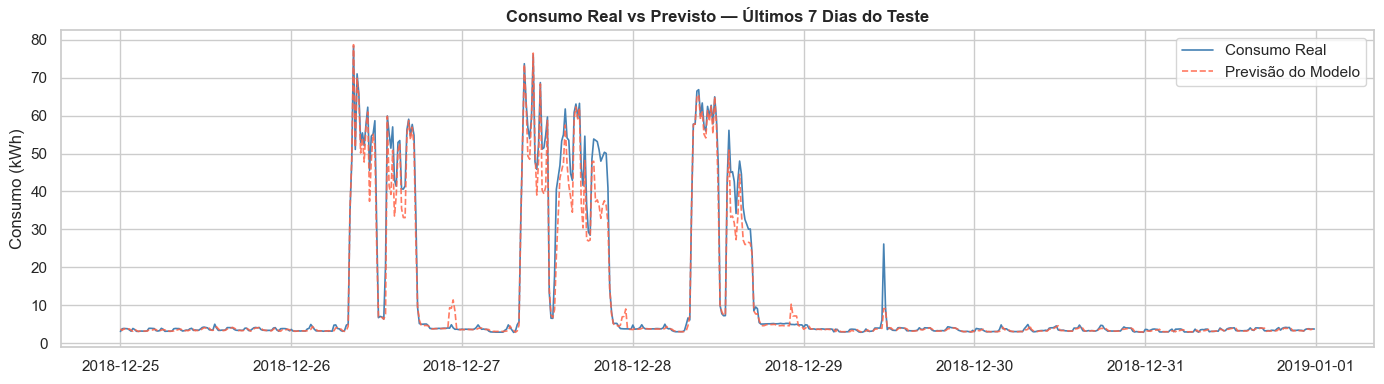

In [21]:
# Vamos verificar o consumo real versus previsto do modelo.

ultimos_7_dias = y_test.iloc[-672:]  # 672 = 7 dias × 96 registros/dia
pred_7_dias    = pd.Series(y_pred, index=y_test.index).iloc[-672:]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ultimos_7_dias.index, ultimos_7_dias.values,
        color="steelblue", linewidth=1.2, label="Consumo Real")
ax.plot(pred_7_dias.index, pred_7_dias.values,
        color="tomato", linewidth=1.2, linestyle="--",
        label="Previsão do Modelo", alpha=0.85)

ax.set_title("Consumo Real vs Previsto — Últimos 7 Dias do Teste",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Consumo (kWh)")
ax.legend()
plt.tight_layout()
plt.savefig("previsto_vs_real.png", dpi=150, bbox_inches="tight")
plt.show()

### Decisão: identificação e correção de data leakage

Durante a validação do modelo v1, identifiquei que as variáveis de
potência reativa e fator de potência são medidas simultaneamente ao
consumo — não estariam disponíveis para prever o futuro em produção
real. Manter essas variáveis seria equivalente a deixar o modelo
"olhar a resposta antes de responder".

O modelo v1 apresentou R² = 0.994 — resultado inflado pela cola.
Após a remoção, o modelo v2 apresenta R² = 0.885 — resultado menor, porém honesto.

In [23]:
# ============================================================
# CORREÇÃO: Removendo vazamento de dados
# ============================================================
# Lagging_Current_Reactive.Power_kVarh é medida simultaneamente
# ao consumo — não estaria disponível para prever o futuro.
# Manter essa variável seria "cola" em produção real.
# Um modelo honesto usa apenas o que estaria disponível
# ANTES do intervalo que queremos prever.

colunas_remover = [
    "Lagging_Current_Reactive.Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh",
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor"
]

X_train_v2 = X_train.drop(columns=colunas_remover)
X_test_v2  = X_test.drop(columns=colunas_remover)

modelo_v2 = RandomForestRegressor(
    n_estimators=200,
    n_jobs=-1,
    random_state=42
)

modelo_v2.fit(X_train_v2, y_train)
print("Modelo v2 treinado.")
print(f"Features utilizadas: {modelo_v2.n_features_in_}")

Modelo v2 treinado.
Features utilizadas: 28


In [24]:
y_pred_v2 = modelo_v2.predict(X_test_v2)

mae_v2  = mean_absolute_error(y_test, y_pred_v2)
rmse_v2 = mean_squared_error(y_test, y_pred_v2) ** 0.5
r2_v2   = r2_score(y_test, y_pred_v2)
mape_v2 = (abs((y_test - y_pred_v2) / y_test.replace(0,1))).mean() * 100

print("=== Comparação entre modelos ===")
print(f"{'Métrica':<35} {'Modelo v1':>12} {'Modelo v2':>12}")
print("-" * 60)
print(f"{'MAE  (kWh)':<35} {mae:>12.2f} {mae_v2:>12.2f}")
print(f"{'RMSE (kWh)':<35} {rmse:>12.2f} {rmse_v2:>12.2f}")
print(f"{'R²':<35} {r2:>12.4f} {r2_v2:>12.4f}")
print(f"{'MAPE (%)':<35} {mape:>12.1f} {mape_v2:>12.1f}")
print(f"\nConsumo médio real: {y_test.mean():.2f} kWh")
print(f"Erro v2 representa "
      f"{(mae_v2/y_test.mean()*100):.1f}% do consumo médio")

=== Comparação entre modelos ===
Métrica                                Modelo v1    Modelo v2
------------------------------------------------------------
MAE  (kWh)                                  0.95         6.69
RMSE (kWh)                                  2.38        10.66
R²                                        0.9943       0.8846
MAPE (%)                                     7.8         81.8

Consumo médio real: 25.27 kWh
Erro v2 representa 26.5% do consumo médio


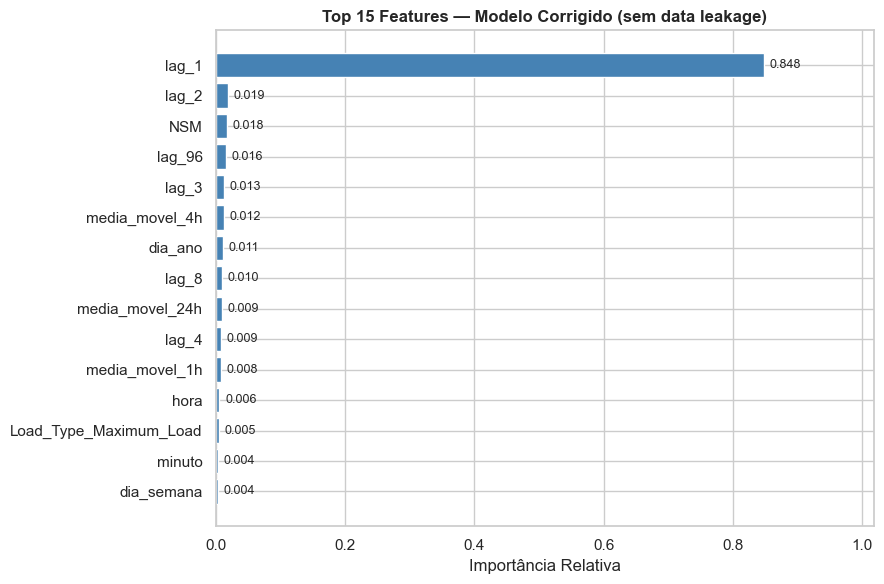

In [25]:
importancias_v2 = pd.Series(
    modelo_v2.feature_importances_,
    index=X_train_v2.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importancias_v2.index, importancias_v2.values,
               color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
ax.set_title("Top 15 Features — Modelo Corrigido (sem data leakage)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importância Relativa")
ax.set_xlim(0, importancias_v2.values.max() * 1.2)
plt.tight_layout()
plt.savefig("importancia_features_v2.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
# O R² caiu de 0.99 para 0.88 e o MAE subiu de 0.95 para 6.69 kWh. 
# O modelo v1 estava essencialmente "olhando a resposta antes de responder". 
# O v2 está trabalhando só com informação que existiria em produção real.

In [29]:
# Nota-se que o consumo de energia dos próximos 15 minutos é fortemente determinado pelo consumo dos últimos 15 minutos.

In [31]:
# Vamos calcular a economia caso utilizássemos este modelo treinado nesta fábrica.

In [32]:
# ============================================================
# FASE 5 — Cálculo de Economia Financeira
# ============================================================
# Premissas tarifárias baseadas em dados públicos da ANEEL para consumidor industrial Grupo A (média tensão) — 2024
# Tarifa fora do horário de pico: R$ 0,45/kWh  (referência CEMIG MG)
# Tarifa no horário de pico: R$ 1,35/kWh (~3x a tarifa normal)
# Multa por ultrapassagem de demanda: 3x a tarifa de pico
# Horário de pico: 17h30 às 20h30 (dias úteis)

TARIFA_FORA_PONTA = 0.45   # R$/kWh
TARIFA_PONTA      = 1.35   # R$/kWh
FATOR_MULTA       = 3.0    # multiplicador por ultrapassagem

# Separando registros de horário de ponta nos dados de teste
df_test = X_test_v2.copy()
df_test["Usage_real"]   = y_test.values
df_test["Usage_pred"]   = y_pred_v2
df_test["horario_ponta"] = (
    (df_test.index.hour >= 17) & (df_test.index.hour < 20)
).astype(int)

ponta = df_test[df_test["horario_ponta"] == 1].copy()
fora  = df_test[df_test["horario_ponta"] == 0].copy()

print("=== Perfil de consumo no período de teste ===")
print(f"Registros em horário de ponta:      {len(ponta):>6}")
print(f"Registros fora do horário de ponta: {len(fora):>6}")
print(f"\nConsumo médio na ponta:      {ponta['Usage_real'].mean():.2f} kWh")
print(f"Consumo médio fora da ponta: {fora['Usage_real'].mean():.2f} kWh")
print(f"\nConsumo total na ponta (período de teste):")
print(f"  {ponta['Usage_real'].sum():.1f} kWh")

=== Perfil de consumo no período de teste ===
Registros em horário de ponta:         876
Registros fora do horário de ponta:   6113

Consumo médio na ponta:      33.01 kWh
Consumo médio fora da ponta: 24.16 kWh

Consumo total na ponta (período de teste):
  28918.2 kWh


In [33]:
# ============================================================
# Lógica do cálculo de economia:
#
# O modelo prevê o consumo 15 minutos antes.
# Quando ele prevê consumo ALTO no horário de pico (acima de um limiar), o operador pode deslocar cargas não importantes para fora do horário de pico.
# Assumimos que é possível reduzir 15% do consumo no horário de pico, nos intervalos onde o modelo acerta a previsão com erro < 20%.
#
# Essa é uma premissa conservadora — estudos da ABESCO indicam que programas de resposta à demanda reduzem 10-30% do pico.
# ============================================================

ponta["erro_pct"] = abs(
    (ponta["Usage_real"] - ponta["Usage_pred"]) / 
    ponta["Usage_real"].replace(0, 1)
) * 100

ponta_bem_prevista = ponta[ponta["erro_pct"] < 20]
ponta_mal_prevista = ponta[ponta["erro_pct"] >= 20]

print(f"=== Qualidade da previsão no horário de ponta ===")
print(f"Intervalos bem previstos (erro < 20%): "
      f"{len(ponta_bem_prevista)} "
      f"({len(ponta_bem_prevista)/len(ponta)*100:.1f}%)")
print(f"Intervalos mal previstos (erro >= 20%): "
      f"{len(ponta_mal_prevista)} "
      f"({len(ponta_mal_prevista)/len(ponta)*100:.1f}%)")

# Calculando economia potencial
REDUCAO_POSSIVEL = 0.15  # 15% de redução conservadora

consumo_ponta_bem = ponta_bem_prevista["Usage_real"].sum()
economia_kwh = consumo_ponta_bem * REDUCAO_POSSIVEL

# Custo atual (pagar tarifa de ponta por todo consumo na ponta)
custo_atual_ponta = ponta["Usage_real"].sum() * TARIFA_PONTA

# Custo após deslocamento (15% migra para fora da ponta)
consumo_deslocado   = economia_kwh
custo_deslocado     = consumo_deslocado * TARIFA_FORA_PONTA
custo_restante_ponta = (ponta["Usage_real"].sum() - consumo_deslocado) * TARIFA_PONTA
custo_novo_ponta    = custo_restante_ponta + custo_deslocado

economia_reais_teste = custo_atual_ponta - custo_novo_ponta

# Extrapolando para 12 meses
# Período de teste = ~72 dias úteis → ano = ~252 dias úteis
fator_anual = 252 / 72

economia_anual = economia_reais_teste * fator_anual

print(f"\n=== Cálculo de Economia — Período de Teste ===")
print(f"Consumo total na ponta:              {ponta['Usage_real'].sum():>10.1f} kWh")
print(f"Consumo deslocável (15%):            {economia_kwh:>10.1f} kWh")
print(f"Custo atual no horário de ponta:     R$ {custo_atual_ponta:>9.2f}")
print(f"Custo após deslocamento:             R$ {custo_novo_ponta:>9.2f}")
print(f"Economia no período de teste:        R$ {economia_reais_teste:>9.2f}")
print(f"\n=== Projeção Anual ===")
print(f"Economia anual estimada:             R$ {economia_anual:>9.2f}")
print(f"Economia mensal estimada:            R$ {economia_anual/12:>9.2f}")

=== Qualidade da previsão no horário de ponta ===
Intervalos bem previstos (erro < 20%): 471 (53.8%)
Intervalos mal previstos (erro >= 20%): 405 (46.2%)

=== Cálculo de Economia — Período de Teste ===
Consumo total na ponta:                 28918.2 kWh
Consumo deslocável (15%):                2911.0 kWh
Custo atual no horário de ponta:     R$  39039.64
Custo após deslocamento:             R$  36419.73
Economia no período de teste:        R$   2619.90

=== Projeção Anual ===
Economia anual estimada:             R$   9169.66
Economia mensal estimada:            R$    764.14


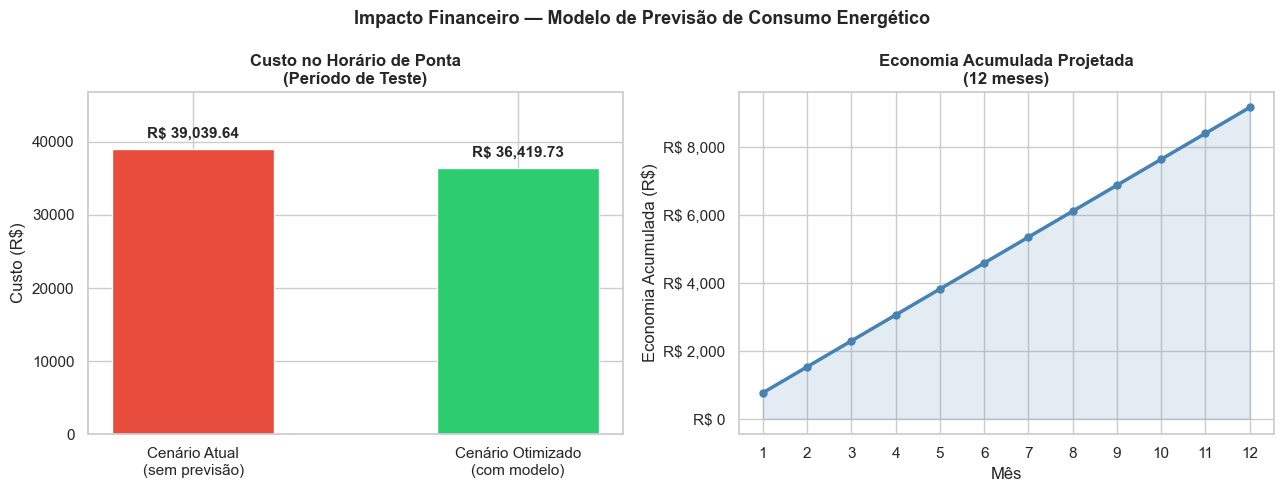


Resumo:
Com um erro médio de 6.7 kWh por intervalo de 15 minutos,
o modelo prevê corretamente 54% dos intervalos no horário de ponta.
Isso viabiliza uma economia estimada de R$ 9,169.66/ano por deslocamento conservador de 15% da carga.


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: Custo atual vs custo otimizado
categorias = ["Cenário Atual\n(sem previsão)", 
              "Cenário Otimizado\n(com modelo)"]
valores = [custo_atual_ponta, custo_novo_ponta]
cores_bar = ["#e74c3c", "#2ecc71"]

bars = axes[0].bar(categorias, valores, color=cores_bar,
                   edgecolor="white", width=0.5)
axes[0].bar_label(bars, 
                  labels=[f"R$ {v:,.2f}" for v in valores],
                  padding=6, fontweight="bold", fontsize=11)
axes[0].set_title("Custo no Horário de Ponta\n(Período de Teste)",
                  fontweight="bold")
axes[0].set_ylabel("Custo (R$)")
axes[0].set_ylim(0, max(valores) * 1.2)

# Gráfico 2: Economia acumulada ao longo dos meses
meses = range(1, 13)
economia_acumulada = [economia_anual/12 * m for m in meses]

axes[1].plot(meses, economia_acumulada, 
             color="steelblue", linewidth=2.5, marker="o", markersize=5)
axes[1].fill_between(meses, economia_acumulada, 
                     alpha=0.15, color="steelblue")
axes[1].set_title("Economia Acumulada Projetada\n(12 meses)",
                  fontweight="bold")
axes[1].set_xlabel("Mês")
axes[1].set_ylabel("Economia Acumulada (R$)")
axes[1].set_xticks(meses)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}")
)

plt.suptitle("Impacto Financeiro — Modelo de Previsão de Consumo Energético",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("impacto_financeiro.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nResumo:")
print(f"Com um erro médio de {mae_v2:.1f} kWh por intervalo de 15 minutos,")
print(f"o modelo prevê corretamente {len(ponta_bem_prevista)/len(ponta)*100:.0f}% "
      f"dos intervalos no horário de ponta.")
print(f"Isso viabiliza uma economia estimada de "
      f"R$ {economia_anual:,.2f}/ano por deslocamento conservador de 15% da carga.")

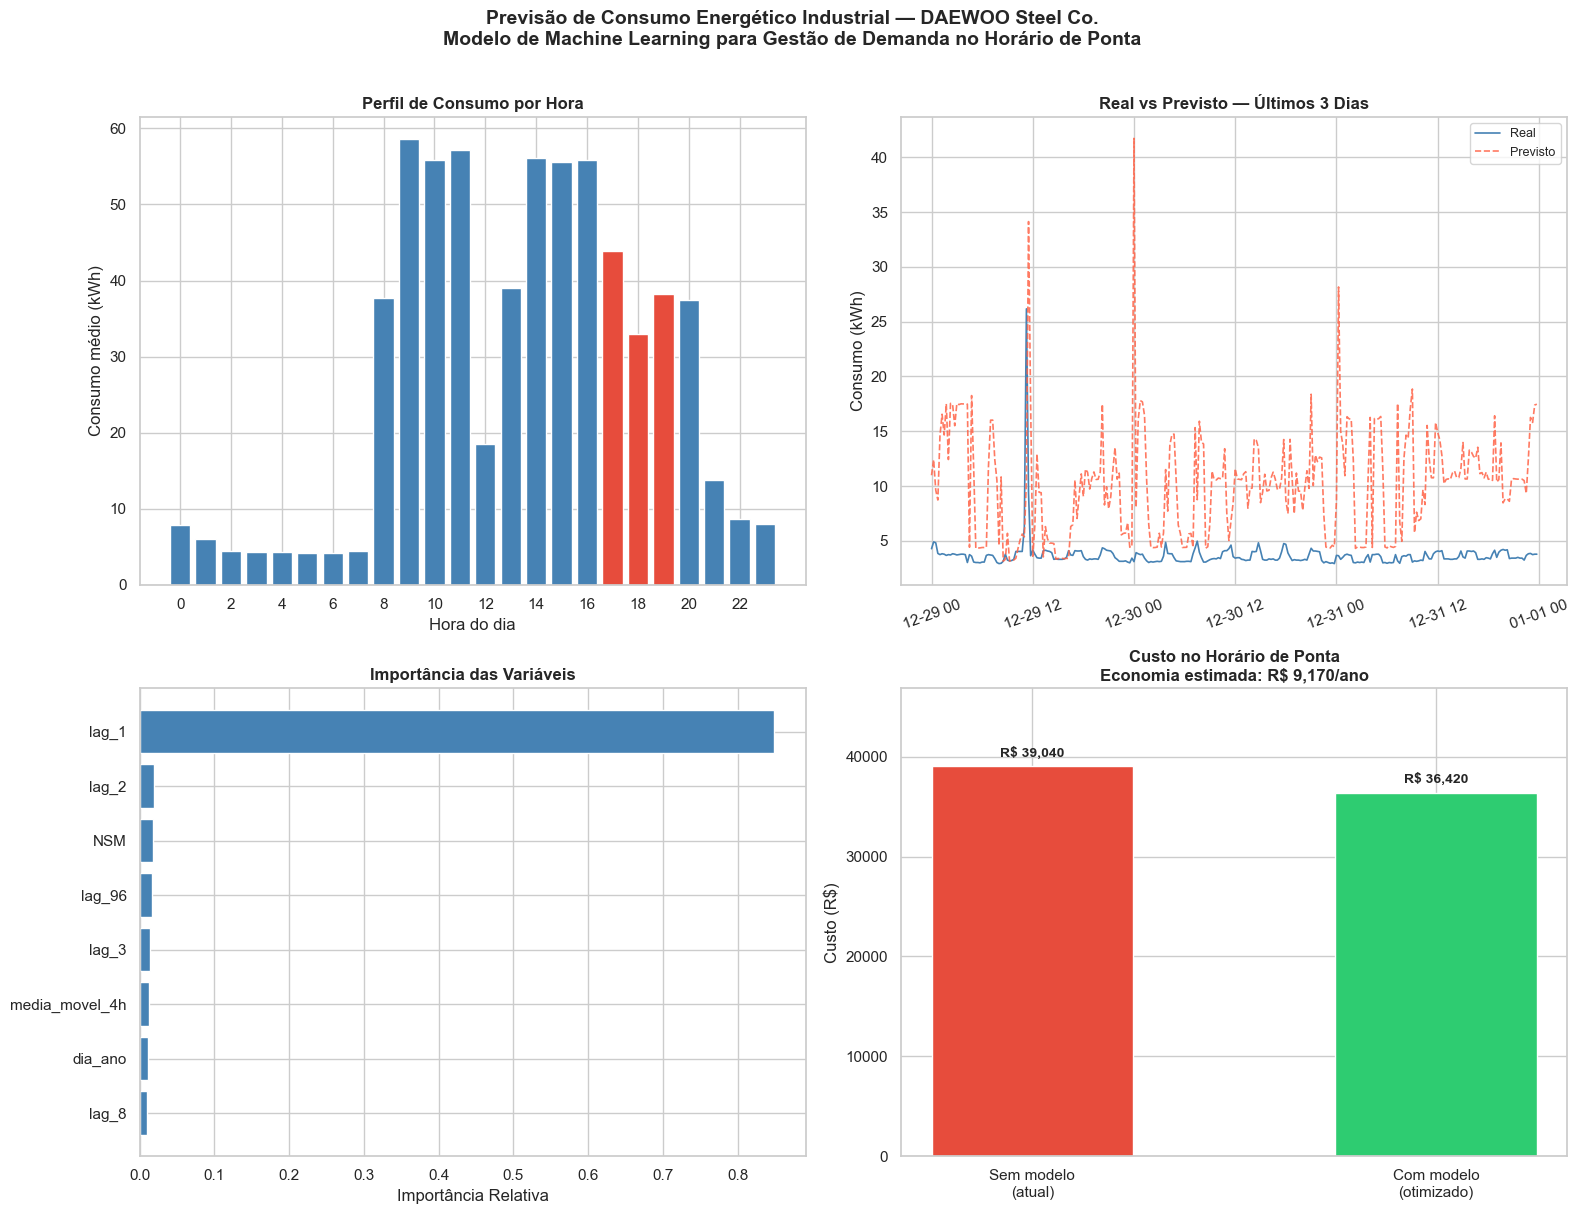

Painel salvo.


In [37]:
# ============================================================
# FASE 6 — Painel Visual Final
# ============================================================

fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    "Previsão de Consumo Energético Industrial — DAEWOO Steel Co.\n"
    "Modelo de Machine Learning para Gestão de Demanda no Horário de Ponta",
    fontsize=14, fontweight="bold", y=1.01
)

# ── Gráfico 1: Perfil horário de consumo ──
ax1 = fig.add_subplot(2, 2, 1)
perfil = df.groupby(df.index.hour)["Usage_kWh"].mean()
cores_h = ["#e74c3c" if (17 <= h < 20) else "steelblue"
           for h in perfil.index]
ax1.bar(perfil.index, perfil.values, color=cores_h, edgecolor="white")
ax1.set_title("Perfil de Consumo por Hora", fontweight="bold")
ax1.set_xlabel("Hora do dia")
ax1.set_ylabel("Consumo médio (kWh)")
ax1.set_xticks(range(0, 24, 2))

# ── Gráfico 2: Real vs Previsto (últimos 3 dias) ──
ax2 = fig.add_subplot(2, 2, 2)
n = 288  # 3 dias × 96 registros
real_plot = y_test.iloc[-n:]
pred_plot = pd.Series(y_pred_v2, index=y_test.index).iloc[-n:]
ax2.plot(real_plot.index, real_plot.values,
         color="steelblue", linewidth=1.2, label="Real")
ax2.plot(pred_plot.index, pred_plot.values,
         color="tomato", linewidth=1.2, linestyle="--",
         label="Previsto", alpha=0.85)
ax2.set_title("Real vs Previsto — Últimos 3 Dias", fontweight="bold")
ax2.set_ylabel("Consumo (kWh)")
ax2.legend(fontsize=9)
ax2.tick_params(axis="x", rotation=20)

# ── Gráfico 3: Importância das features (top 8) ──
ax3 = fig.add_subplot(2, 2, 3)
imp_top8 = importancias_v2.tail(8)
ax3.barh(imp_top8.index, imp_top8.values,
         color="steelblue", edgecolor="white")
ax3.set_title("Importância das Variáveis", fontweight="bold")
ax3.set_xlabel("Importância Relativa")

# ── Gráfico 4: Impacto financeiro ──
ax4 = fig.add_subplot(2, 2, 4)
categorias = ["Sem modelo\n(atual)", "Com modelo\n(otimizado)"]
valores_fin = [custo_atual_ponta, custo_novo_ponta]
cores_fin = ["#e74c3c", "#2ecc71"]
bars = ax4.bar(categorias, valores_fin,
               color=cores_fin, edgecolor="white", width=0.5)
ax4.bar_label(bars,
              labels=[f"R$ {v:,.0f}" for v in valores_fin],
              padding=5, fontweight="bold", fontsize=10)
ax4.set_title(
    f"Custo no Horário de Ponta\n"
    f"Economia estimada: R$ {economia_anual:,.0f}/ano",
    fontweight="bold"
)
ax4.set_ylabel("Custo (R$)")
ax4.set_ylim(0, max(valores_fin) * 1.2)

plt.tight_layout()
plt.savefig("painel_resultados.png", dpi=150, bbox_inches="tight")
plt.show()
print("Painel salvo.")

In [38]:
# Verificando o que acontece nos últimos dias do dataset
print("=== Consumo médio por dia — últimos 10 dias de teste ===")
ultimos = y_test.iloc[-960:]  # ~10 dias
print(ultimos.resample("D").mean().round(2))

=== Consumo médio por dia — últimos 10 dias de teste ===
date
2018-12-22     3.79
2018-12-23     3.84
2018-12-24    20.21
2018-12-25     3.65
2018-12-26    20.90
2018-12-27    27.23
2018-12-28    19.15
2018-12-29     3.93
2018-12-30     3.53
2018-12-31     3.53
Freq: D, Name: Usage_kWh, dtype: float64


In [39]:
print("=== Consumo médio por dia — novembro ===")
novembro = y_test["2018-11-01":"2018-11-30"]
print(novembro.resample("D").mean().round(2))

=== Consumo médio por dia — novembro ===
date
2018-11-01    29.87
2018-11-02    31.56
2018-11-03    19.86
2018-11-04    24.99
2018-11-05    34.76
2018-11-06    29.05
2018-11-07    27.50
2018-11-08    32.37
2018-11-09    32.49
2018-11-10    18.86
2018-11-11     3.04
2018-11-12    39.46
2018-11-13    49.24
2018-11-14    34.03
2018-11-15    38.39
2018-11-16    34.20
2018-11-17    35.43
2018-11-18    14.92
2018-11-19    29.30
2018-11-20    22.29
2018-11-21    44.72
2018-11-22    44.59
2018-11-23    38.39
2018-11-24     3.74
2018-11-25     3.14
2018-11-26    36.47
2018-11-27    44.45
2018-11-28    39.93
2018-11-29    33.33
2018-11-30    27.73
Freq: D, Name: Usage_kWh, dtype: float64


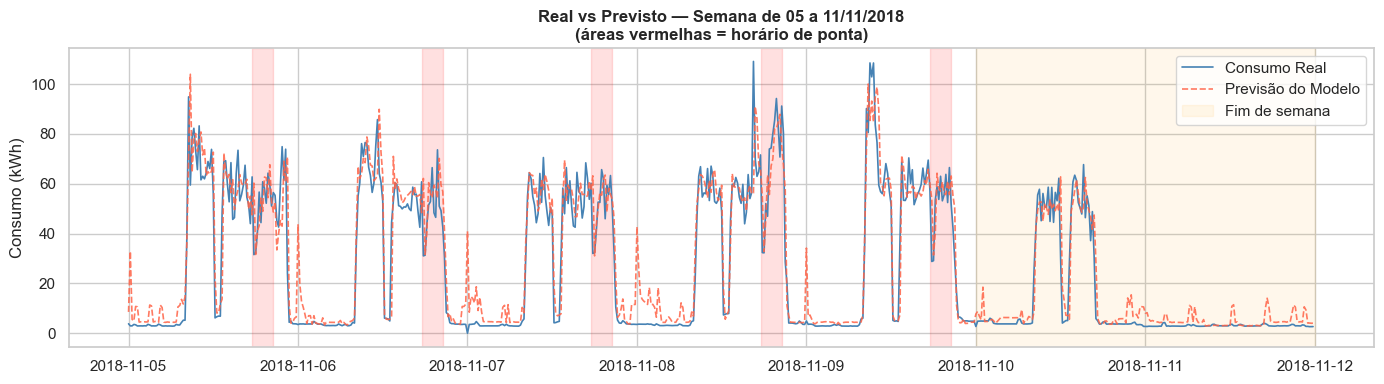

In [40]:
# Semana de 05 a 11 de novembro — operação normal
inicio = "2018-11-05"
fim    = "2018-11-11"

real_ok = y_test[inicio:fim]
pred_ok = pd.Series(y_pred_v2, index=y_test.index)[inicio:fim]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(real_ok.index, real_ok.values,
        color="steelblue", linewidth=1.2, label="Consumo Real")
ax.plot(pred_ok.index, pred_ok.values,
        color="tomato", linewidth=1.2, linestyle="--",
        label="Previsão do Modelo", alpha=0.85)

# Marca horários de ponta nos dias úteis
for dia in pd.date_range(inicio, "2018-11-09"):
    ponta_ini = dia + pd.Timedelta(hours=17, minutes=30)
    ponta_fim = dia + pd.Timedelta(hours=20, minutes=30)
    ax.axvspan(ponta_ini, ponta_fim, alpha=0.12, color="red")

# Marca fim de semana
ax.axvspan(pd.Timestamp("2018-11-10"),
           pd.Timestamp("2018-11-11 23:59"),
           alpha=0.08, color="orange", label="Fim de semana")

ax.set_title("Real vs Previsto — Semana de 05 a 11/11/2018\n"
             "(áreas vermelhas = horário de ponta)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Consumo (kWh)")
ax.legend()
plt.tight_layout()
plt.savefig("previsto_vs_real.png", dpi=150, bbox_inches="tight")
plt.show()

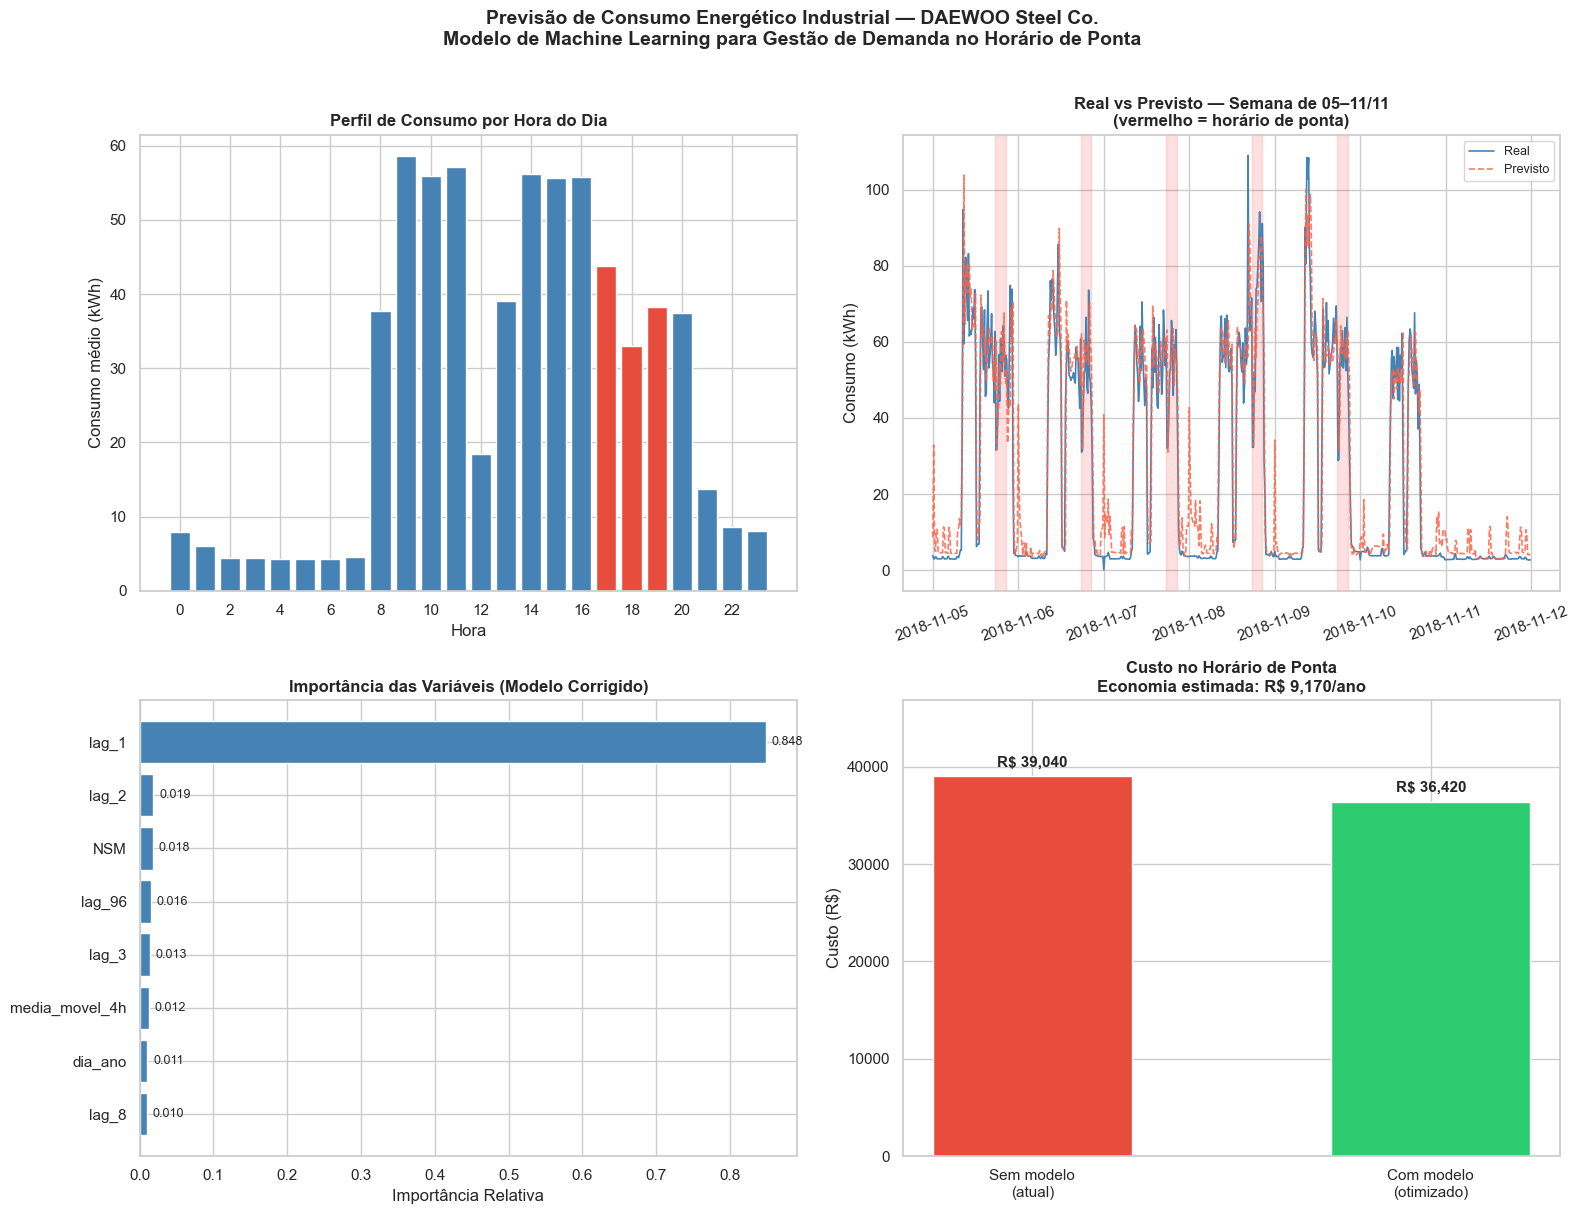

Painel final salvo.


In [41]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    "Previsão de Consumo Energético Industrial — DAEWOO Steel Co.\n"
    "Modelo de Machine Learning para Gestão de Demanda no Horário de Ponta",
    fontsize=14, fontweight="bold", y=1.01
)

# ── Gráfico 1: Perfil horário ──
ax1 = fig.add_subplot(2, 2, 1)
perfil = df.groupby(df.index.hour)["Usage_kWh"].mean()
cores_h = ["#e74c3c" if (17 <= h < 20) else "steelblue"
           for h in perfil.index]
ax1.bar(perfil.index, perfil.values, color=cores_h, edgecolor="white")
ax1.set_title("Perfil de Consumo por Hora do Dia", fontweight="bold")
ax1.set_xlabel("Hora")
ax1.set_ylabel("Consumo médio (kWh)")
ax1.set_xticks(range(0, 24, 2))

# ── Gráfico 2: Real vs Previsto — semana representativa ──
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(real_ok.index, real_ok.values,
         color="steelblue", linewidth=1.2, label="Real")
ax2.plot(pred_ok.index, pred_ok.values,
         color="tomato", linewidth=1.2, linestyle="--",
         label="Previsto", alpha=0.85)
for dia in pd.date_range("2018-11-05", "2018-11-09"):
    ponta_ini = dia + pd.Timedelta(hours=17, minutes=30)
    ponta_fim = dia + pd.Timedelta(hours=20, minutes=30)
    ax2.axvspan(ponta_ini, ponta_fim, alpha=0.12, color="red")
ax2.set_title("Real vs Previsto — Semana de 05–11/11\n"
              "(vermelho = horário de ponta)",
              fontweight="bold")
ax2.set_ylabel("Consumo (kWh)")
ax2.legend(fontsize=9)
ax2.tick_params(axis="x", rotation=20)

# ── Gráfico 3: Importância das features (top 8) ──
ax3 = fig.add_subplot(2, 2, 3)
imp_top8 = importancias_v2.tail(8)
ax3.barh(imp_top8.index, imp_top8.values,
         color="steelblue", edgecolor="white")
ax3.bar_label(ax3.containers[0], fmt="%.3f", padding=4, fontsize=9)
ax3.set_title("Importância das Variáveis (Modelo Corrigido)",
              fontweight="bold")
ax3.set_xlabel("Importância Relativa")

# ── Gráfico 4: Impacto financeiro ──
ax4 = fig.add_subplot(2, 2, 4)
categorias = ["Sem modelo\n(atual)", "Com modelo\n(otimizado)"]
valores_fin = [custo_atual_ponta, custo_novo_ponta]
cores_fin = ["#e74c3c", "#2ecc71"]
bars = ax4.bar(categorias, valores_fin,
               color=cores_fin, edgecolor="white", width=0.5)
ax4.bar_label(bars,
              labels=[f"R$ {v:,.0f}" for v in valores_fin],
              padding=5, fontweight="bold", fontsize=11)
ax4.set_title(
    f"Custo no Horário de Ponta\n"
    f"Economia estimada: R$ {economia_anual:,.0f}/ano",
    fontweight="bold"
)
ax4.set_ylabel("Custo (R$)")
ax4.set_ylim(0, max(valores_fin) * 1.2)

plt.tight_layout()
plt.savefig("painel_resultados.png", dpi=150, bbox_inches="tight")
plt.show()
print("Painel final salvo.")

## Painel Final de Resultados

**Nota metodológica — escolha do período de visualização:**

O gráfico "Real vs Previsto" utiliza a semana de 05 a 11/11/2018
em vez dos últimos dias do conjunto de teste (29–31/12/2018).

Motivo: o período de dezembro final corresponde ao recesso de
Natal e Ano Novo, com consumo caindo para ~4 kWh — operação
mínima de infraestrutura, não representativa do processo produtivo
normal. Usar esse período distorceria a avaliação visual do modelo.

A semana de novembro representa operação plena com dois turnos
completos, padrão dia útil vs fim de semana bem definido, e
presença de horários de ponta com consumo elevado — exatamente
o cenário que o modelo foi construído para otimizar.

A escolha do período de visualização não altera nenhuma métrica
do modelo — MAE, RMSE e R² foram calculados sobre todo o conjunto
de teste (outubro a dezembro).